# Chapter 4: Regression and Prediction

## Introduction

Regression is a statistical method used to study the relationship between a response variable and one or more predictor variables. It can be used to explain relationships and predict outcomes for new observations.

In data science, regression is a supervised learning technique because the model is trained using data with known outcomes.

## Learning Objectives

* Understand simple and multiple linear regression.
* Interpret regression equations, coefficients, fitted values, and residuals.
* Evaluate regression models using RMSE and R-squared.
* Understand cross-validation and model selection.
* Explore prediction intervals and categorical predictors.
* Identify multicollinearity, outliers, and influential observations.
* Explore polynomial regression and nonlinear relationships.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
# Simulated housing dataset
n = 100

house_size = np.random.randint(500, 3500, n)
bedrooms = np.random.randint(1, 6, n)

price = (
    50000
    + 180 * house_size
    + 15000 * bedrooms
    + np.random.normal(0, 30000, n)
)

house = pd.DataFrame({
    "HouseSize": house_size,
    "Bedrooms": bedrooms,
    "Price": price
})

house.head()

,HouseSize,Bedrooms,Price
0,1360,4,397805.464619
1,1794,3,449893.811256
2,1630,3,313437.225751
3,1595,1,396509.856835
4,2138,3,544601.855701


## 1. Simple Linear Regression

Simple linear regression models the relationship between one predictor variable \(X\) and a response variable \(Y\).

The regression equation is:

$$
Y = b_0 + b_1X
$$

Here, \(b_0\) is the intercept and \(b_1\) is the slope. The slope represents the expected change in the predicted response for a one-unit increase in the predictor.


Intercept: 98490.60736181628
Slope: 177.70397131470068


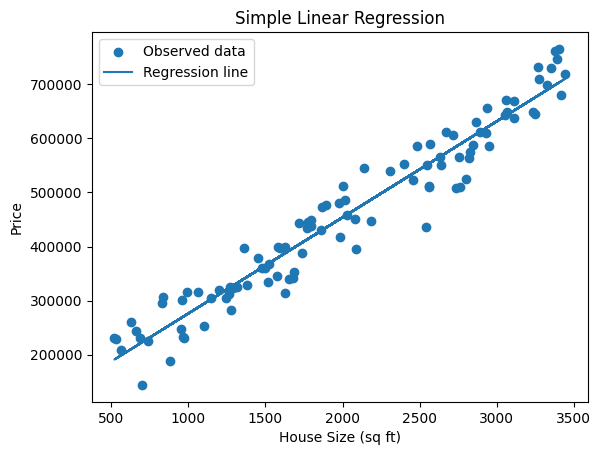

In [ ]:
X = house[["HouseSize"]]
y = house["Price"]

simple_model = LinearRegression()
simple_model.fit(X, y)

print("Intercept:", simple_model.intercept_)
print("Slope:", simple_model.coef_[0])

predicted_price = simple_model.predict(X)

plt.scatter(house["HouseSize"], y, label="Observed data")
plt.plot(house["HouseSize"], predicted_price, label="Regression line")
plt.xlabel("House Size (sq ft)")
plt.ylabel("Price")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

## 2. Fitted Values and Residuals

Fitted values are the values predicted by a regression model for the observations used to fit it.

A residual is the difference between the observed response and the fitted value:

$$
e_i = y_i - \hat{y}_i
$$

Residuals help evaluate how well the model represents the observed data.


In [ ]:
house["FittedPrice"] = simple_model.predict(house[["HouseSize"]])
house["Residual"] = house["Price"] - house["FittedPrice"]

house[["HouseSize", "Price", "FittedPrice", "Residual"]].head()

,HouseSize,Price,FittedPrice,Residual
0,1360,397805.464619,340168.008350,57637.456269
1,1794,449893.811256,417291.531900,32602.279356
2,1630,313437.225751,388148.080605,-74710.854854
3,1595,396509.856835,381928.441609,14581.415226
4,2138,544601.855701,478421.698033,66180.157668


## 3. Least Squares

Ordinary least squares estimates regression coefficients by minimizing the sum of squared residuals.

$$
SSE = \sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

Squaring the residuals prevents positive and negative errors from canceling each other and penalizes larger errors more heavily.


In [ ]:
sse = np.sum(house["Residual"] ** 2)

print("Sum of Squared Errors (SSE):", sse)

Sum of Squared Errors (SSE): 147385361165.34354


## 4. Prediction Versus Explanation

Prediction focuses on estimating outcomes for observations whose responses are not yet known.

Explanation focuses on understanding the relationship between predictors and the response. A model that predicts accurately does not automatically establish a causal relationship.


In [ ]:
example_size = pd.DataFrame({"HouseSize": [1500, 2000, 2500]})
example_predictions = simple_model.predict(example_size)

for size, prediction in zip(example_size["HouseSize"], example_predictions):
    print(f"House size: {size} sq ft -> Predicted price: {prediction:.2f}")

House size: 1500 sq ft -> Predicted price: 365046.56
House size: 2000 sq ft -> Predicted price: 453898.55
House size: 2500 sq ft -> Predicted price: 542750.54


## 5. Multiple Linear Regression

Multiple linear regression uses two or more predictor variables to estimate a response.

$$
Y=b_0+b_1X_1+b_2X_2+\cdots+b_pX_p+\epsilon
$$

Each coefficient represents the estimated relationship between a predictor and the response while holding the other included predictors constant.


In [ ]:
X_multiple = house[["HouseSize", "Bedrooms"]]
y = house["Price"]

multiple_model = LinearRegression()
multiple_model.fit(X_multiple, y)

print("Intercept:", multiple_model.intercept_)

for feature, coefficient in zip(
    X_multiple.columns, multiple_model.coef_
):
    print(f"{feature} coefficient: {coefficient:.2f}")

Intercept: 53938.614275974745
HouseSize coefficient: 178.44
Bedrooms coefficient: 15006.01


## 6. Assessing the Model

Regression models can be evaluated using metrics such as root mean squared error (RMSE) and R-squared.

* **RMSE:** Measures the typical scale of prediction errors, in the response variable's units.
* **R-squared:** Measures the proportion of variation in the response explained by the fitted model, as defined for the evaluated data.

A model should not be judged by a single metric alone.


In [ ]:
y_pred = multiple_model.predict(X_multiple)

rmse = np.sqrt(mean_squared_error(y, y_pred))
r_squared = r2_score(y, y_pred)

print("RMSE:", rmse)
print("R-squared:", r_squared)

RMSE: 31952.06669484428
R-squared: 0.9580502973972651


## 7. Cross-Validation

Cross-validation estimates how well a model may perform on unseen data. In k-fold cross-validation, the data are divided into k folds. The model is trained on all but one fold and evaluated on the remaining fold, repeating the process until each fold has been used for evaluation.


In [ ]:
X = house[["HouseSize", "Bedrooms"]]
y = house["Price"]

cv_model = LinearRegression()

cv_scores = cross_val_score(
    cv_model,
    X,
    y,
    cv=5,
    scoring="neg_mean_squared_error"
)

cv_rmse = np.sqrt(-cv_scores)

print("RMSE for each fold:", cv_rmse)
print("Mean cross-validation RMSE:", cv_rmse.mean())

RMSE for each fold: [34798.74971875 26900.13957286 33684.08823218 33829.86323519
 33251.90932448]
Mean cross-validation RMSE: 32492.950016688865


## 8. Model Selection

Model selection involves choosing predictors and model complexity appropriate to the problem. Adding predictors can improve fit on training data without improving predictions on unseen data.

Stepwise regression is one approach to selecting predictors by adding or removing variables according to a specified criterion. Any selection process should be evaluated carefully to avoid overfitting.


In [ ]:
# Compare models using five-fold cross-validation
model_size = LinearRegression()
model_size_bedrooms = LinearRegression()

scores_size = cross_val_score(
    model_size,
    house[["HouseSize"]],
    y,
    cv=5,
    scoring="neg_mean_squared_error"
)

scores_both = cross_val_score(
    model_size_bedrooms,
    house[["HouseSize", "Bedrooms"]],
    y,
    cv=5,
    scoring="neg_mean_squared_error"
)

print("House size only - mean CV RMSE:",
      np.sqrt(-scores_size).mean())

print("House size and bedrooms - mean CV RMSE:",
      np.sqrt(-scores_both).mean())

House size only - mean CV RMSE: 39130.38998264554
House size and bedrooms - mean CV RMSE: 32492.950016688865


## 9. Weighted Regression

Weighted regression assigns different weights to observations when fitting a model. It can be useful when observations have different levels of precision or importance.

The choice of weights should be justified by the data and the study design.


In [ ]:
# Demonstration using illustrative observation weights
weights = np.ones(len(house))
weights[house["HouseSize"] > 2500] = 2.0

weighted_model = LinearRegression()
weighted_model.fit(
    house[["HouseSize", "Bedrooms"]],
    house["Price"],
    sample_weight=weights
)

print("Weighted regression coefficients:")
print("Intercept:", weighted_model.intercept_)
print("Coefficients:", weighted_model.coef_)

Weighted regression coefficients:
Intercept: 50554.77316988917
Coefficients: [  179.07123557 15370.20341102]


## 10. Prediction Using Regression

After a model is fitted, it can predict the response for new observations. Predictions should be made within the range and context supported by the training data whenever possible.


In [ ]:
new_houses = pd.DataFrame({
    "HouseSize": [1200, 1800, 2800],
    "Bedrooms": [2, 3, 4]
})

new_houses["PredictedPrice"] = multiple_model.predict(new_houses)

new_houses

,HouseSize,Bedrooms,PredictedPrice
0,1200,2,298078.060877
1,1800,3,420147.784178
2,2800,4,613593.313933


## 11. The Dangers of Extrapolation

Extrapolation means using a model to predict outside the range of predictor values represented in the training data. Relationships observed within the data may not continue beyond that range, so extrapolated predictions can be unreliable.


In [ ]:
observed_min = house["HouseSize"].min()
observed_max = house["HouseSize"].max()

print("Observed house-size range:", observed_min, "to", observed_max)

test_sizes = pd.DataFrame({
    "HouseSize": [
        observed_min - 1000,
        observed_min,
        observed_max,
        observed_max + 1000
    ]
})

test_sizes["PredictedPrice"] = simple_model.predict(test_sizes)
test_sizes

Observed house-size range: 521 to 3445


,HouseSize,PredictedPrice
0,-479,13370.405102
1,521,191074.376417
2,3445,710680.788541
3,4445,888384.759856


## 12. Confidence and Prediction Intervals

A confidence interval quantifies uncertainty about a population parameter or a mean response. A prediction interval quantifies uncertainty about an individual future observation and is generally wider because it includes individual-level variation.

This demonstration uses bootstrap resampling to illustrate uncertainty in the fitted mean prediction.


In [ ]:
# Bootstrap illustration for the mean response at a house size
rng = np.random.default_rng(42)
bootstrap_predictions = []
n = len(house)
target_size = 2000

for _ in range(500):
    indices = rng.choice(n, size=n, replace=True)
    sample = house.iloc[indices]

    boot_model = LinearRegression()
    boot_model.fit(sample[["HouseSize"]], sample["Price"])

    prediction = boot_model.predict(
        pd.DataFrame({"HouseSize": [target_size]})
    )[0]

    bootstrap_predictions.append(prediction)

lower, upper = np.percentile(bootstrap_predictions, [2.5, 97.5])

print("Predicted mean price at 2000 sq ft:",
      simple_model.predict(pd.DataFrame({"HouseSize": [target_size]}))[0])
print("Bootstrap 95% interval for mean prediction:", (lower, upper))

Predicted mean price at 2000 sq ft: 453898.5499912176
Bootstrap 95% interval for mean prediction: (np.float64(446566.062603672), np.float64(461587.67128292593))


## 13. Factor Variables in Regression

Factor variables represent categorical information, such as property type, region, or building condition. Regression models can include categorical predictors by converting their categories into numerical indicator variables.


In [ ]:
house["Condition"] = np.random.choice(
    ["Standard", "Renovated", "NeedsRepair"],
    size=len(house)
)

house_encoded = pd.get_dummies(
    house[["HouseSize", "Bedrooms", "Condition"]],
    columns=["Condition"],
    drop_first=True,
    dtype=int
)

factor_model = LinearRegression()
factor_model.fit(house_encoded, house["Price"])

print("Predictors:", house_encoded.columns.tolist())
print("Coefficients:", factor_model.coef_)

Predictors: ['HouseSize', 'Bedrooms', 'Condition_Renovated', 'Condition_Standard']
Coefficients: [  177.64719169 14855.0609549  -8567.77095327 -6645.30303541]


## 14. Dummy Variables Representation

Dummy variables encode categories using binary values, typically 0 and 1. When a model includes an intercept, one category is commonly omitted as the reference category to avoid perfect linear dependence among all category indicators.


In [ ]:
print("Dummy-variable dataset:")
display(house_encoded.head())

print("Reference category: Standard")

Dummy-variable dataset:


,HouseSize,Bedrooms,Condition_Renovated,Condition_Standard
0,1360,4,0,0
1,1794,3,0,1
2,1630,3,1,0
3,1595,1,0,0
4,2138,3,1,0


Reference category: Standard


## 12. Confidence and Prediction Intervals

A confidence interval quantifies uncertainty about a population parameter or a mean response. A prediction interval quantifies uncertainty about an individual future observation and is generally wider because it includes individual-level variation.

This demonstration uses bootstrap resampling to illustrate uncertainty in the fitted mean prediction.


In [ ]:
# Bootstrap illustration for the mean response at a house size
rng = np.random.default_rng(42)
bootstrap_predictions = []
n = len(house)
target_size = 2000

for _ in range(500):
    indices = rng.choice(n, size=n, replace=True)
    sample = house.iloc[indices]

    boot_model = LinearRegression()
    boot_model.fit(sample[["HouseSize"]], sample["Price"])

    prediction = boot_model.predict(
        pd.DataFrame({"HouseSize": [target_size]})
    )[0]

    bootstrap_predictions.append(prediction)

lower, upper = np.percentile(bootstrap_predictions, [2.5, 97.5])

print("Predicted mean price at 2000 sq ft:",
      simple_model.predict(pd.DataFrame({"HouseSize": [target_size]}))[0])
print("Bootstrap 95% interval for mean prediction:", (lower, upper))

Predicted mean price at 2000 sq ft: 453898.5499912176
Bootstrap 95% interval for mean prediction: (np.float64(446566.062603672), np.float64(461587.67128292593))


## 13. Factor Variables in Regression

Factor variables represent categorical information, such as property type, region, or building condition. Regression models can include categorical predictors by converting their categories into numerical indicator variables.


In [ ]:
house["Condition"] = np.random.choice(
    ["Standard", "Renovated", "NeedsRepair"],
    size=len(house)
)

house_encoded = pd.get_dummies(
    house[["HouseSize", "Bedrooms", "Condition"]],
    columns=["Condition"],
    drop_first=True,
    dtype=int
)

factor_model = LinearRegression()
factor_model.fit(house_encoded, house["Price"])

print("Predictors:", house_encoded.columns.tolist())
print("Coefficients:", factor_model.coef_)

Predictors: ['HouseSize', 'Bedrooms', 'Condition_Renovated', 'Condition_Standard']
Coefficients: [  177.83591976 14426.28445942 20500.01327821  7193.13676864]


## 14. Dummy Variables Representation

Dummy variables encode categories using binary values, typically 0 and 1. When a model includes an intercept, one category is commonly omitted as the reference category to avoid perfect linear dependence among all category indicators.


In [ ]:
print("Dummy-variable dataset:")
display(house_encoded.head())

print("Reference category: Standard")

Dummy-variable dataset:


,HouseSize,Bedrooms,Condition_Renovated,Condition_Standard
0,1360,4,1,0
1,1794,3,1,0
2,1630,3,1,0
3,1595,1,0,1
4,2138,3,1,0


Reference category: Standard


## 15. Interpreting the Regression Equation

A regression coefficient describes the expected change in the predicted response associated with a one-unit increase in a predictor, holding the other predictors constant. Interpretation depends on the units, coding, and assumptions of the model.


In [ ]:
for feature, coefficient in zip(
    house_encoded.columns, factor_model.coef_
):
    print(f"{feature}: {coefficient:.2f}")

HouseSize: 177.84
Bedrooms: 14426.28
Condition_Renovated: 20500.01
Condition_Standard: 7193.14


## 16. Correlated Predictors and Multicollinearity

Predictors may be correlated with one another. Multicollinearity occurs when predictors in a regression model have strong linear relationships. It can make coefficient estimates less stable and harder to interpret, even when the model's predictions remain useful.


In [ ]:
print("Predictor correlation matrix:")
display(house[["HouseSize", "Bedrooms"]].corr())

Predictor correlation matrix:


,HouseSize,Bedrooms
HouseSize,1.000000,-0.029396
Bedrooms,-0.029396,1.000000


## 17. Confounding Variables

A confounding variable is associated with both a predictor and the response and may distort the apparent relationship between them. Including relevant variables can help with interpretation, but regression alone does not guarantee that a causal effect has been identified.


In [ ]:
# Compare the simple and multiple regression coefficients
print("Simple regression slope for HouseSize:",
      simple_model.coef_[0])

print("Multiple regression coefficients:")
for feature, coefficient in zip(
    X_multiple.columns, multiple_model.coef_
):
    print(f"{feature}: {coefficient:.2f}")

Simple regression slope for HouseSize: 177.70397131470068
Multiple regression coefficients:
HouseSize: 178.44
Bedrooms: 15006.01


## 18. Interactions and Main Effects

An interaction occurs when the relationship between one predictor and the response depends on the value of another predictor. A model with interaction terms can represent relationships that differ across groups or predictor values.


In [ ]:
interaction_data = house.copy()
interaction_data["Size_Bedrooms"] = (
    interaction_data["HouseSize"]
    * interaction_data["Bedrooms"]
)

X_interaction = interaction_data[
    ["HouseSize", "Bedrooms", "Size_Bedrooms"]
]

interaction_model = LinearRegression()
interaction_model.fit(X_interaction, interaction_data["Price"])

print("Interaction-model coefficients:",
      interaction_model.coef_)

Interaction-model coefficients: [1.76161217e+02 1.34663673e+04 7.58088663e-01]


## 19. Regression Diagnostics

Regression diagnostics examine whether a model fits the data adequately and whether its assumptions are plausible. Residual plots can help reveal unusual observations, nonlinearity, changing variance, and other patterns that a model may not capture.


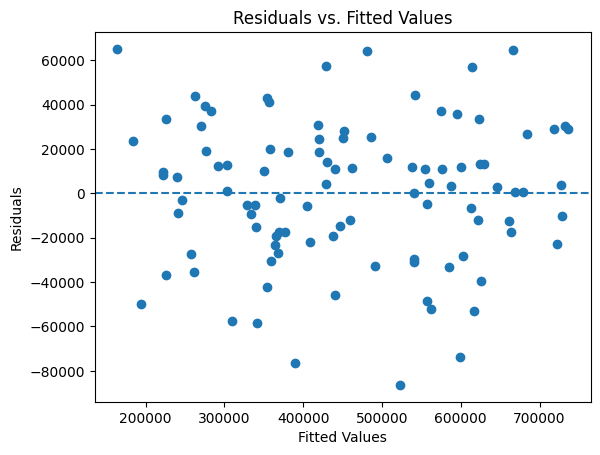

In [ ]:
diagnostic_predictions = multiple_model.predict(X_multiple)
diagnostic_residuals = y - diagnostic_predictions

plt.scatter(diagnostic_predictions, diagnostic_residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted Values")
plt.show()

## 20. Outliers and Influential Values

An outlier is an observation that differs substantially from the overall pattern. An influential observation is one that has a notable effect on the fitted model. An observation can be an outlier without being highly influential, so both residual size and influence should be considered.


In [ ]:
residual_std = diagnostic_residuals.std(ddof=1)

outlier_mask = (
    np.abs(diagnostic_residuals)
    > 2 * residual_std
)

print("Potential outlier count:", outlier_mask.sum())
display(house.loc[outlier_mask])

Potential outlier count: 5


,HouseSize,Bedrooms,Price,FittedPrice,Residual,Condition
2,1630,3,313437.225751,388148.080605,-74710.854854,Renovated
25,2800,3,524909.034048,596061.727043,-71152.692995,Standard
52,2541,1,435996.293196,550036.398472,-114040.105277,NeedsRepair
62,534,1,229320.354741,193384.528044,35935.826697,Standard
84,3267,2,731626.586367,679049.481647,52577.104720,Renovated


## 21. Heteroskedasticity, Non-Normality, and Correlated Errors

Heteroskedasticity occurs when the variance of the errors changes across predictor or fitted values. Non-normal errors and correlated errors can also affect certain forms of statistical inference. Residual plots and other diagnostics can help identify potential issues.


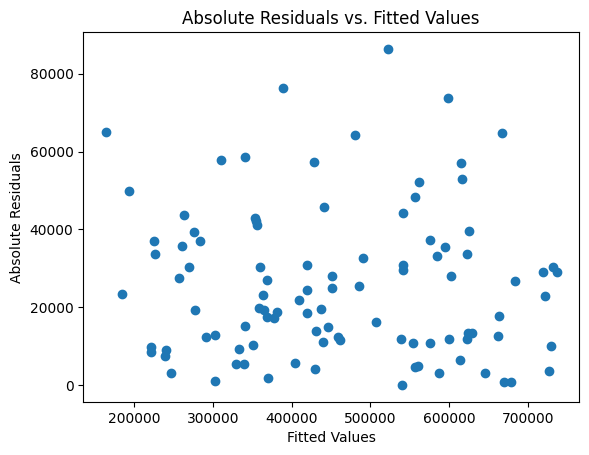

In [ ]:
plt.scatter(
    diagnostic_predictions,
    np.abs(diagnostic_residuals)
)
plt.xlabel("Fitted Values")
plt.ylabel("Absolute Residuals")
plt.title("Absolute Residuals vs. Fitted Values")
plt.show()

## 22. Partial Residual Plots and Nonlinearity

A linear model may fail to capture a nonlinear relationship. Examining relationships between predictors and the response, alongside residual diagnostics, can help identify whether a straight-line relationship is adequate.


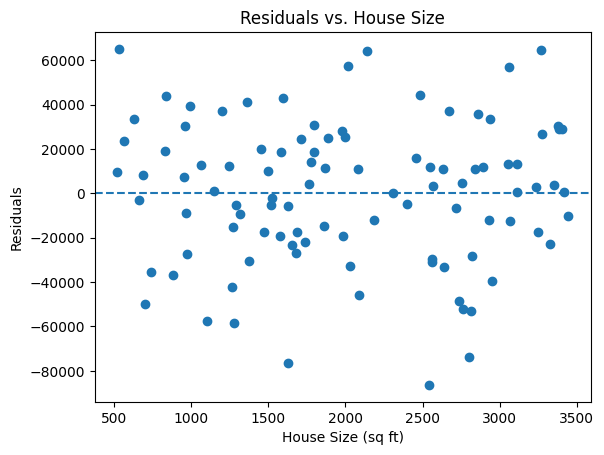

In [ ]:
plt.scatter(house["HouseSize"], diagnostic_residuals)
plt.axhline(0, linestyle="--")
plt.xlabel("House Size (sq ft)")
plt.ylabel("Residuals")
plt.title("Residuals vs. House Size")
plt.show()

## 23. Polynomial Regression

Polynomial regression extends linear regression by including powers of a predictor, such as \(X^2\) or \(X^3\). The model remains linear in its coefficients but can represent curved relationships between the predictor and response.


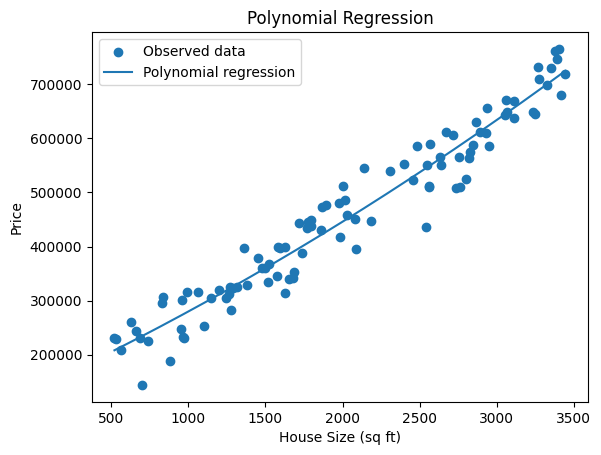

In [ ]:
X_size = house[["HouseSize"]]
y = house["Price"]

polynomial_model = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression()
)

polynomial_model.fit(X_size, y)

size_grid = pd.DataFrame({
    "HouseSize": np.linspace(
        house["HouseSize"].min(),
        house["HouseSize"].max(),
        200
    )
})

poly_predictions = polynomial_model.predict(size_grid)

plt.scatter(house["HouseSize"], y, label="Observed data")
plt.plot(size_grid["HouseSize"], poly_predictions,
         label="Polynomial regression")
plt.xlabel("House Size (sq ft)")
plt.ylabel("Price")
plt.title("Polynomial Regression")
plt.legend()
plt.show()

## 24. Splines

Splines model nonlinear relationships using piecewise polynomial functions joined at selected points called knots. They offer flexibility while controlling how the fitted curve behaves across different regions of the predictor range.


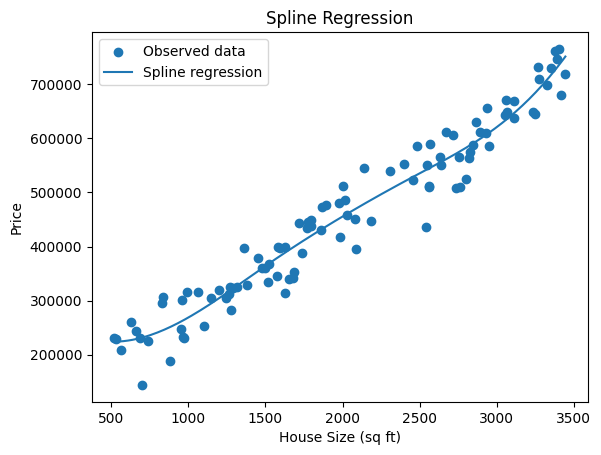

In [ ]:
from sklearn.preprocessing import SplineTransformer

spline_model = make_pipeline(
    SplineTransformer(n_knots=4, degree=3),
    LinearRegression()
)

spline_model.fit(X_size, y)
spline_predictions = spline_model.predict(size_grid)

plt.scatter(house["HouseSize"], y, label="Observed data")
plt.plot(size_grid["HouseSize"], spline_predictions,
         label="Spline regression")
plt.xlabel("House Size (sq ft)")
plt.ylabel("Price")
plt.title("Spline Regression")
plt.legend()
plt.show()